<a href="https://colab.research.google.com/github/jma199/business-marketing-case-study/blob/main/Customer_Churn_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn

## 1. Business Problem

The business is losing customers. We need to identify which customers are at highest risk and what factors are driving their departure, so retention efforts can be targeted effectively.

## 2. Exploratory Data Analysis

Load the data, understand what's in it, and clean it up where needed.



In [1]:
# Upload dataset

# Import packages
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.stats import chi2_contingency

In [2]:
df = pd.read_excel('Telco_customer_churn.xlsx')
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [3]:
# List of all column headers
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [4]:
# List of columns
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

This dataset has information for:
- customer information (eg. location, family/dependents)
- services subscribed
- account information (length of tenure, type of contract, payment method)
- financial information
- target variable: whether the customer left this quarter or not
- customers reason for leaving

The churn label tells us whether the customer left this quarter or stayed and the churn value tells us the same thing, where 0 represent customers who stayed and 1 represents customers that left.

Some data types are incorrect and will be fixed when needed.

This dataset is already pretty clean, so the dataset has non-null values in the churn reason column, presumably no reason for those who didn't churn.

### 2.1 Define the baseline of customer churn

In [5]:
# Determine how many options for churn are
counts = df['Churn Label'].value_counts()
print(f'The number of unique data values in Churn Label is {len(counts)}.')
print(counts)

The number of unique data values in Churn Label is 2.
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64


In [6]:
# Define a function to calculate the churn rate and retention rate of customers overall
def churn_baseline(df, churn_col, churn_val='Yes'):
    counts = df[churn_col].value_counts()
    churned = counts.get(churn_val, 0)
    total = len(df)
    retained = total - churned
    return {
        'total': total,
        'churned': churned,
        'retained': retained,
        'churn_rate': round(churned / total * 100, 1),
        'retention_rate': round(retained / total * 100, 1)
    }

baseline = churn_baseline(df, churn_col='Churn Label')
print(baseline)

{'total': 7043, 'churned': np.int64(1869), 'retained': np.int64(5174), 'churn_rate': np.float64(26.5), 'retention_rate': np.float64(73.5)}


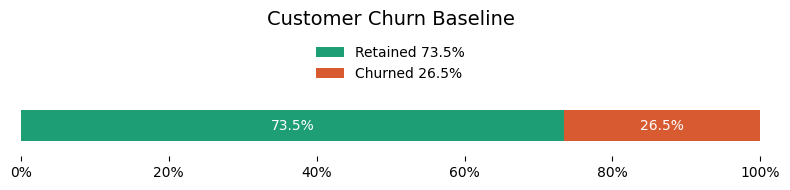

In [7]:
def plot_churn_baseline(df, churn_col='Churn Label', churn_val='Yes'):
    """
    Plots churn baseline as a horizontal bar chart.
    """
    fig, ax = plt.subplots(figsize=(8, 2))

    total = len(df)
    churned = (df[churn_col] == churn_val).sum()
    retained = total - churned
    churn_rate = round(churned / total * 100, 1)
    retention_rate = round(retained / total * 100, 1)

    # Draw the retained bar
    bar_retained = ax.barh(0, retention_rate, color='#1D9E75', height=0.1, label=f'Retained {retention_rate}%')
    # Draw the churned bar, stacked after the retained bar
    bar_churned = ax.barh(0, churn_rate, color='#D85A30', height=0.1, left=retention_rate, label=f'Churned {churn_rate}%')

    # Add churn rate text on each bar
    # For retained bar
    for bar in bar_retained:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
                f'{retention_rate:.1f}%', va='center', ha='center', color='white', fontsize=10)
    # For churned bar
    for bar in bar_churned:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
                f'{churn_rate:.1f}%', va='center', ha='center', color='white', fontsize=10)

    ax.set_title('Customer Churn Baseline', fontsize=14)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_xlim(0, 100) # Max 100% for stacked bar
    ax.set_ylim(-0.1, 0.3)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_yticks([]) # Remove y-ticks for single bar
    ax.legend(frameon=False, loc='upper center')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False) # Hide left spine for cleaner look
    ax.spines['bottom'].set_visible(False) # Hide bottom spine
    plt.tight_layout()
    plt.show()

plot_churn_baseline(df, churn_col='Churn Label', churn_val='Yes')

The baseline churn is 26.5%.

### 2.2 Demographic Factors

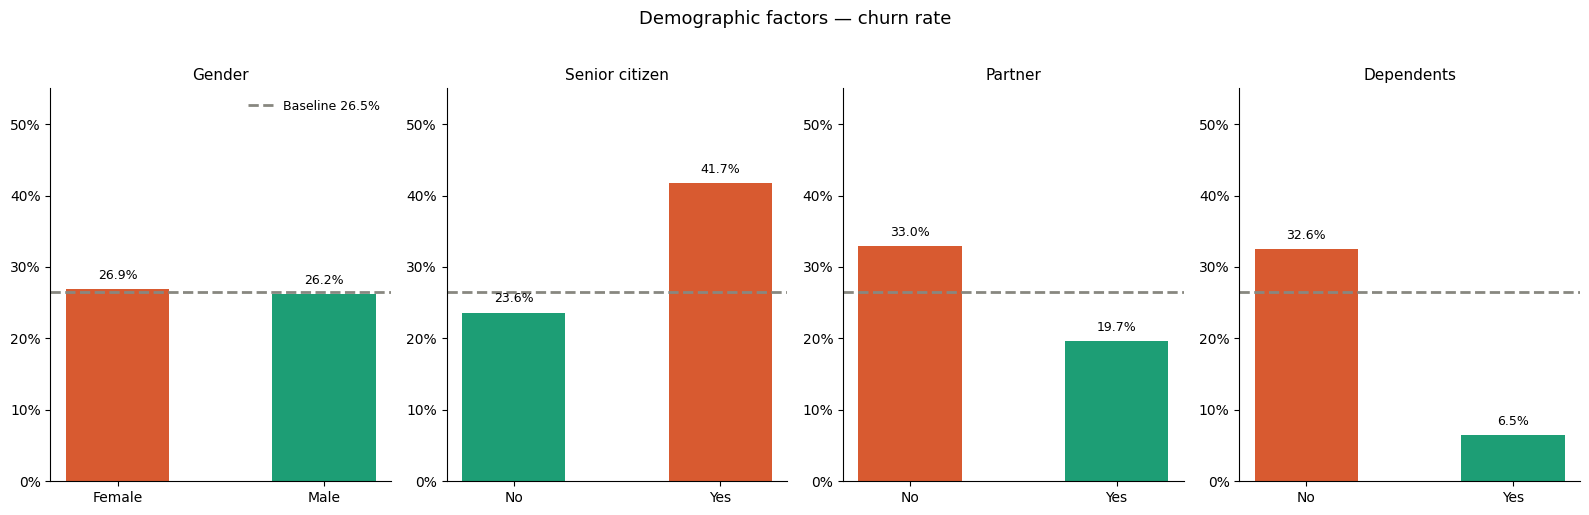

In [8]:
def plot_demographic_factors(df, churn_col, churn_val='Yes'):
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    fig.suptitle('Demographic factors — churn rate', fontsize=13, y=1.02)

    features = ['Gender', 'Senior Citizen', 'Partner', 'Dependents']
    titles = ['Gender', 'Senior citizen', 'Partner', 'Dependents']
    threshold = baseline['churn_rate']  # baseline churn rate

    for ax, feature, title in zip(axes, features, titles):
        churn_rates = (
            df.groupby(feature)[churn_col]
            .apply(lambda x: (x == churn_val).mean() * 100)
            .reset_index(name='churn_rate')
        )

        bar_colors = [
            '#D85A30' if r > threshold else '#1D9E75'
            for r in churn_rates['churn_rate']
        ]

        bars = ax.bar(churn_rates[feature].astype(str),
               churn_rates['churn_rate'],
               color=bar_colors, width=0.5)

        # Add churn rate text above each bar
        for bar in bars:
            yval = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom', fontsize=9, color='black')

        # baseline reference line
        ax.axhline(threshold, color='#888780', linewidth=2,
                   linestyle='--', label=f'Baseline {threshold}%')

        ax.set_title(title, fontsize=11)
        ax.set_ylim(0, 55)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        ax.tick_params(axis='x', labelsize=10)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    axes[0].legend(fontsize=9, frameon=False)
    plt.tight_layout()
    plt.show()


plot_demographic_factors(df, churn_col='Churn Label', churn_val='Yes')

In [9]:
# calculate whether there is a significant different using chi-squared test

demographic_features = ['Gender', 'Senior Citizen', 'Partner', 'Dependents']
churn_column = 'Churn Label'

print('Chi-squared test results for demographic factors vs. Churn Label:')
print('----------------------------------------------------------------')

for feature in demographic_features:
    contingency_table = pd.crosstab(df[feature], df[churn_column])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    print(f'\nFeature: {feature}')
    print(f'Chi-squared statistic: {chi2:.2f}')
    print(f'P-value: {p_value:.5f}')

    if p_value < 0.05:
        print('Interpretation: There is a statistically significant association between this feature and customer churn (p < 0.05).')
    else:
        print('Interpretation: There is no statistically significant association between this feature and customer churn (p >= 0.05).')


Chi-squared test results for demographic factors vs. Churn Label:
----------------------------------------------------------------

Feature: Gender
Chi-squared statistic: 0.48
P-value: 0.48658
Interpretation: There is no statistically significant association between this feature and customer churn (p >= 0.05).

Feature: Senior Citizen
Chi-squared statistic: 159.43
P-value: 0.00000
Interpretation: There is a statistically significant association between this feature and customer churn (p < 0.05).

Feature: Partner
Chi-squared statistic: 158.73
P-value: 0.00000
Interpretation: There is a statistically significant association between this feature and customer churn (p < 0.05).

Feature: Dependents
Chi-squared statistic: 433.73
P-value: 0.00000
Interpretation: There is a statistically significant association between this feature and customer churn (p < 0.05).


Three clear takeaways:

- Gender is essentially irrelevant — a 0.7% gap is negligible and not statistically significant.

- Senior citizens churn at nearly double the rate of non-seniors (41.7% vs 23.6%)

- Customers with partners or dependents churn significantly less, suggesting household stability and financial commitment may reduce churn risk.



### 2.3 Account Factors

Account factors include how a customer paid, the type of contract (month-to-month or by the year).

In [10]:
# check the Tenure Length feature stats
df['Tenure Months'].describe()

,Tenure Months
count,7043.000000
mean,32.371149
std,24.559481
min,0.000000
25%,9.000000
50%,29.000000
75%,55.000000
max,72.000000


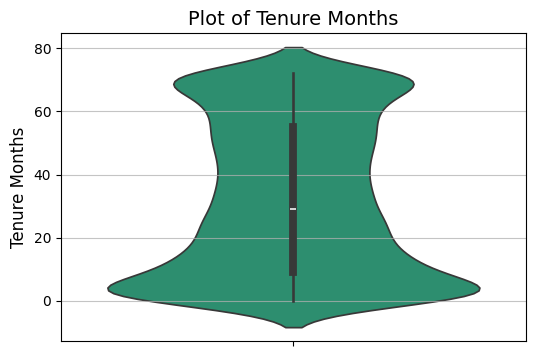

In [11]:
# plot the distribution of length of tenure of each customer in months
plt.figure(figsize=(6, 4))
sns.violinplot(y=df['Tenure Months'], color='#1D9E75')
plt.title('Plot of Tenure Months', fontsize=14)
plt.ylabel('Tenure Months', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()

In [12]:
def account_factors(df, churn_col, churn_val='Yes'):
    results = {}

    # categorical factors
    for col in ['Contract', 'Payment Method']:
        results[col] = (
            df.groupby(col)[churn_col]
            .apply(lambda x: round((x == churn_val).mean() * 100, 1))
            .to_dict()
        )

    # tenure by churn status
    results['tenure_avg'] = (
        df.groupby(churn_col)['Tenure Months']
        .mean()
        .round(1)
        .to_dict()
    )

    # tenure distribution by band
    df['tenure_band'] = pd.cut(
        df['Tenure Months'],
        bins=[0, 12, 24, 36, 48, 60, 72],
        labels=['0–12mo', '13–24mo', '25–36mo', '37–48mo', '49–60mo', '61–72mo']
    )
    results['tenure_distribution'] = (
        df.groupby(['tenure_band', churn_col], observed=False) # observed=False to suppress FutureWarning
        .size()
        .groupby(level=0)
        .apply(lambda x: round(x / x.sum() * 100, 1))
        .unstack(churn_col)
        .to_dict()
    )

    return results

factors = account_factors(df, "Churn Label")

/tmp/ipykernel_7154/983671647.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(level=0)


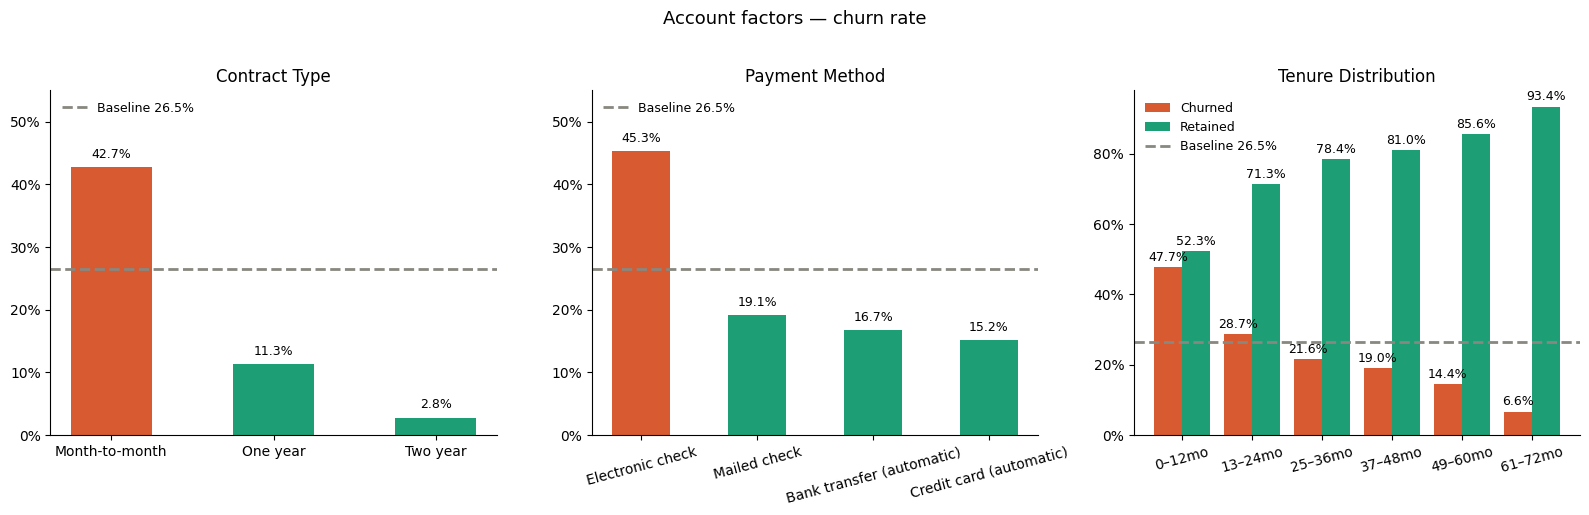

In [13]:
def plot_account_factors(factors):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle('Account factors \u2014 churn rate', fontsize=13, y=1.02) # Add a subtitle

    # baseline reference line
    threshold = baseline['churn_rate']  # baseline churn rate

    # contract type
    contract = factors['Contract']
    contract_bars = axes[0].bar(contract.keys(), contract.values(),
                color=['#D85A30' if v > threshold else '#1D9E75' for v in contract.values()], # Compare with threshold
                width=0.5)
    axes[0].set_title('Contract Type')
    axes[0].set_ylim(0, 55)

    # payment method
    payment = dict(sorted(factors['Payment Method'].items(),
                          key=lambda x: x[1], reverse=True))
    payment_bars = axes[1].bar(payment.keys(), payment.values(),
                color=['#D85A30' if v > threshold else '#1D9E75' for v in payment.values()], # Compare with threshold
                width=0.5)
    axes[1].set_title('Payment Method')
    axes[1].tick_params(axis='x', rotation=15)
    axes[1].set_ylim(0, 55)

    # tenure distribution
    tenure_dist = factors['tenure_distribution']
    churned_vals = [tenure_dist['Yes'][b] for b in tenure_dist['Yes']]
    retained_vals = [tenure_dist['No'][b] for b in tenure_dist['No']]

    # Extract the first element from the tuple keys for display
    bands = [b[0] for b in tenure_dist['Yes'].keys()]
    x = range(len(bands))
    # Plotting bars for tenure, these will have their own labels for legend
    bar_churned = axes[2].bar([i - 0.2 for i in x], churned_vals, width=0.4,
                color='#D85A30', label='Churned')
    bar_retained = axes[2].bar([i + 0.2 for i in x], retained_vals, width=0.4,
                color='#1D9E75', label='Retained')
    axes[2].set_xticks(list(x))
    axes[2].set_xticklabels(bands)
    axes[2].set_title('Tenure Distribution')
    axes[2].tick_params(axis='x', rotation=15)

    # Add text labels on top of bars for all plots
    for ax_idx, current_ax in enumerate(axes):
        # For bar plots, use ax.containers
        if ax_idx < 2: # For contract type and payment method
            for bar in current_ax.containers[0]: # Assuming single container for these plots
                yval = bar.get_height()
                current_ax.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom', fontsize=9, color='black')
        else: # For tenure distribution with two bar containers
            for container in current_ax.containers:
                for bar in container:
                    yval = bar.get_height()
                    current_ax.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom', fontsize=9, color='black')

    # Process each axis for common formatting and legends
    for i, ax in enumerate(axes):
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # Draw the baseline WITHOUT a label, add manually to legends
        ax.axhline(threshold, color='#888780', linewidth=2, linestyle='--')

        # Create a Line2D object for the baseline to be used in legends
        baseline_line = mlines.Line2D([], [], color='#888780', linestyle='--', linewidth=2, label=f'Baseline {threshold}%')

        # For the tenure distribution plot (i == 2), combine legends
        if i == 2:
            # Get handles and labels for the 'Churned' and 'Retained' bars
            handles, labels = ax.get_legend_handles_labels()
            # Add the baseline line to the existing handles and labels
            handles.append(baseline_line)
            labels.append(f'Baseline {threshold}%')
            ax.legend(handles=handles, labels=labels, fontsize=9, frameon=False, loc='upper left')
        else:
            # For other plots (contract, payment method), only show the baseline legend
            # We explicitly create a legend with just the baseline_line
            ax.legend(handles=[baseline_line], labels=[f'Baseline {threshold}%'], fontsize=9, frameon=False, loc='upper left')


    plt.tight_layout()
    plt.show()

# usage
plot_account_factors(factors)

Here are the key takeaways:

    - Contract Type: Customers on month-to-month contracts have a significantly higher churn rate (42.7%) compared to those with one-year (11.3%) or two-year (2.8%) contracts. This suggests that longer-term contracts help in retaining customers.
    - Payment Method: Customers using Electronic Check as their payment method show the highest churn rate (45.3%). In contrast, other methods like Bank Transfer and Credit Card have much lower churn rates (around 15-17%). This indicates that customers paying via electronic check are more prone to churning.
    - Tenure Distribution: There's a clear trend where churn is much higher among newer customers (e.g., 47.7% churn for 0–12 months tenure). As customer tenure increases, the churn rate significantly drops, showing that long-term customers are much more loyal.


### 2.4 Internet Service and Add-On Factors

The type of internet services offered are DSL or fiber-optic. If an internet service is provided, varoius add-ons are available including online security or file backup services, device protection, tech support, and TV or movie streaming.

In [14]:
# Look at the churn rate for each of the internet service options.
def calculate_internet_service_churn(df, churn_col, churn_val='Yes'):
    results = {}
    internet_features = [
        'Internet Service', 'Online Security', 'Online Backup',
        'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies'
    ]

    for feature in internet_features:
        # Ensure 'No internet service' is handled correctly, it implies 'No' for add-ons
        if feature != 'Internet Service':
            # For add-on services, calculate churn only for customers with internet service
            # And treat 'No internet service' as 'No' for the add-on
            temp_df = df.copy()
            temp_df.loc[temp_df['Internet Service'] == 'No', feature] = 'No'
            churn_rates = temp_df.groupby(feature)[churn_col].apply(lambda x: round((x == churn_val).mean() * 100, 1)).to_dict()
        else:
            # For Internet Service itself, calculate directly
            churn_rates = df.groupby(feature)[churn_col].apply(lambda x: round((x == churn_val).mean() * 100, 1)).to_dict()

        results[feature] = churn_rates

    return results

internet_churn_data = calculate_internet_service_churn(df, churn_col='Churn Label')
# print(internet_churn_data)

In [15]:
# Table of internet churn data
pd.DataFrame(internet_churn_data)

,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies
DSL,19.0,NaN,NaN,NaN,NaN,NaN,NaN
Fiber optic,41.9,NaN,NaN,NaN,NaN,NaN,NaN
No,7.4,31.3,29.2,28.7,31.2,24.3,24.4
Yes,NaN,14.6,21.5,22.5,15.2,30.1,29.9


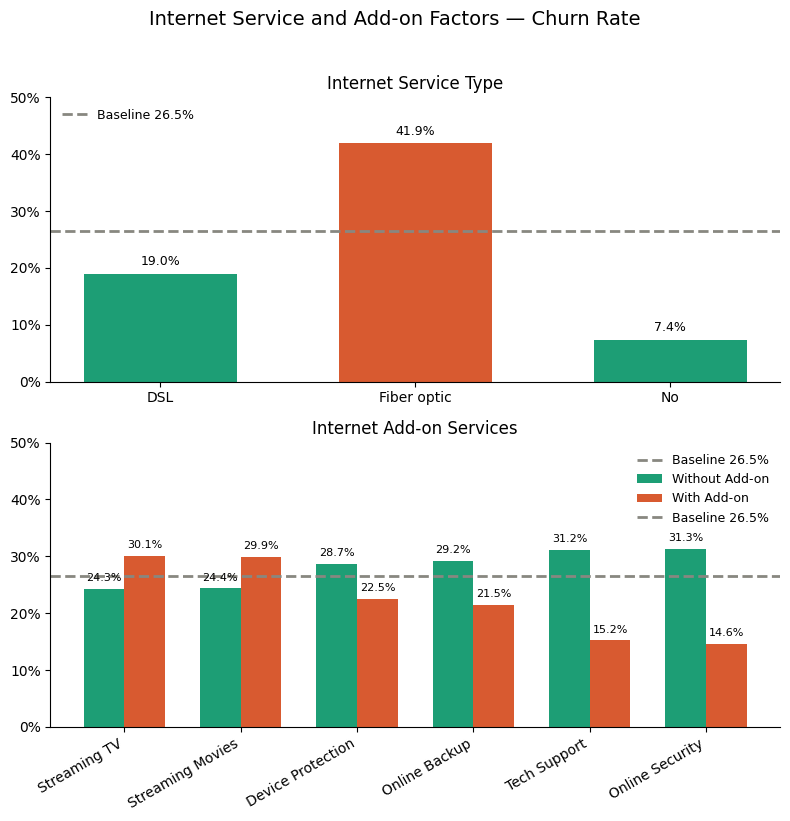

In [16]:
def plot_internet_service_churn(internet_churn_data, baseline_churn_rate):
    fig, axes = plt.subplots(2, 1, figsize=(8, 8))
    fig.suptitle('Internet Service and Add-on Factors — Churn Rate', fontsize=14, y=1.02)

    # --- Plot 1: Internet Service Type ---
    ax1 = axes[0]
    internet_service_data = internet_churn_data['Internet Service']
    service_types = list(internet_service_data.keys())
    churn_rates = list(internet_service_data.values())

    colors = ['#D85A30' if rate > baseline_churn_rate else '#1D9E75' for rate in churn_rates]
    bars1 = ax1.bar(service_types, churn_rates, color=colors, width=0.6)

    ax1.set_title('Internet Service Type', fontsize=12)
    ax1.set_ylim(0, 50)
    ax1.axhline(baseline_churn_rate, color='#888780', linestyle='--', linewidth=2, label=f'Baseline {baseline_churn_rate}%')
    ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.tick_params(axis='x', labelsize=10)
    ax1.legend(fontsize=9, frameon=False, loc='upper left')

    # Add percentage labels on bars
    for bar in bars1:
        yval = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom', fontsize=9, color='black')

    # --- Plot 2: Internet Add-on Services ---
    ax2 = axes[1]
    add_on_features_raw = ['Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies']

    # Prepare data for sorting
    add_on_data_list = []
    for feature in add_on_features_raw:
        churn_no_rate = internet_churn_data[feature].get('No', 0.0)
        churn_yes_rate = internet_churn_data[feature].get('Yes', 0.0)
        add_on_data_list.append((feature, churn_no_rate, churn_yes_rate))

    # Sort by 'No' churn rate in ascending order
    add_on_data_list_sorted = sorted(add_on_data_list, key=lambda x: x[1])

    # Reconstruct lists based on sorted order
    add_on_labels = [item[0] for item in add_on_data_list_sorted]
    churn_no = [item[1] for item in add_on_data_list_sorted]
    churn_yes = [item[2] for item in add_on_data_list_sorted]

    x = range(len(add_on_features_raw))
    width = 0.35

    bars_no = ax2.bar([p - width/2 for p in x], churn_no, width, label='Without Add-on', color='#1D9E75') # Changed color to green
    bars_yes = ax2.bar([p + width/2 for p in x], churn_yes, width, label='With Add-on', color='#D85A30') # Fixed color to orange

    ax2.set_title('Internet Add-on Services', fontsize=12)
    ax2.set_xticks(x)
    ax2.set_xticklabels(add_on_labels, rotation=30, ha='right', fontsize=10)
    ax2.set_ylim(0, 50)
    ax2.axhline(baseline_churn_rate, color='#888780', linestyle='--', linewidth=2, label=f'Baseline {baseline_churn_rate}%')
    ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    # Create a Line2D object for the baseline to be used in legends
    baseline_line = mlines.Line2D([], [], color='#888780', linestyle='--', linewidth=2, label=f'Baseline {baseline_churn_rate}%')

    # Get handles and labels for the 'No Service' and 'Has Service' bars
    handles, labels = ax2.get_legend_handles_labels()
    # Add the baseline line to the existing handles and labels
    handles.append(baseline_line)
    labels.append(f'Baseline {baseline_churn_rate}%')
    ax2.legend(handles=handles, labels=labels, fontsize=9, frameon=False, loc='upper right')

    # Add percentage labels on bars
    for bars_collection in [bars_no, bars_yes]:
        for bar in bars_collection:
            yval = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom', fontsize=8, color='black')

    plt.tight_layout()
    plt.show()

plot_internet_service_churn(internet_churn_data, baseline['churn_rate'])

Key Takeaways:


*   The fiber optic customers churn double the rate of DSL customers.
*   Security and support add-ons have the strongest impact on retaining customers
*   Streaming services have the least impact on retaining customers







### 2.5 Financial Factors

#### 2.5.1 Average Charges

Determine the impact of the amount charged to a customer on churn.

In [17]:
def calculate_average_cost_by_churn(df, churn_col='Churn Label', churn_val='Yes'):
    # Make a copy to avoid modifying the original DataFrame
    df_copy = df.copy()

    # Ensure 'Total Charges' is numeric, coercing errors to NaN
    df_copy['Total Charges'] = pd.to_numeric(df_copy['Total Charges'], errors='coerce')

    # Drop rows where 'Total Charges' is NaN after coercion (these are likely empty strings)
    df_copy.dropna(subset=['Total Charges'], inplace=True)

    # Group by churn status and calculate the mean and standard deviation of monthly and total charges
    avg_costs = df_copy.groupby(churn_col)[['Monthly Charges', 'Total Charges']].agg(['mean', 'std', 'count'])
    return avg_costs

# Call the function and display the results
avg_costs_by_churn = calculate_average_cost_by_churn(df)
print("Average Monthly and Total Charges by Churn Status:")
print(avg_costs_by_churn)

Average Monthly and Total Charges by Churn Status:
            Monthly Charges                  Total Charges                   
                       mean        std count          mean          std count
Churn Label                                                                  
No                61.307408  31.094557  5163   2555.344141  2329.456984  5163
Yes               74.441332  24.666053  1869   1531.796094  1890.822994  1869


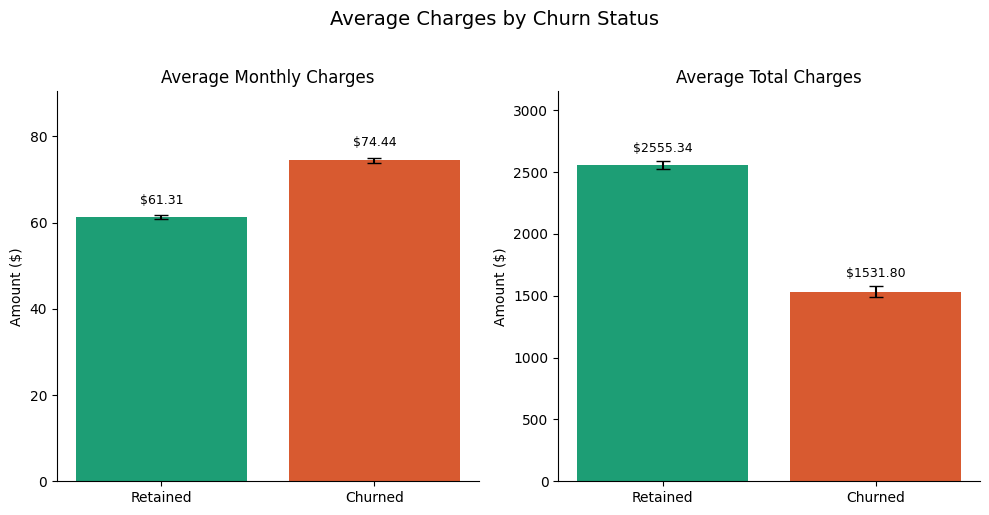

In [18]:
def plot_ave_churn_cost(avg_costs_df):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle('Average Charges by Churn Status', fontsize=14, y=1.02)

    # Plot 1: Average Monthly Charges
    monthly_means = avg_costs_df['Monthly Charges']['mean']
    monthly_stds = avg_costs_df['Monthly Charges']['std']
    monthly_counts = avg_costs_df['Monthly Charges']['count']
    monthly_sems = monthly_stds / (monthly_counts**0.5) # Standard Error of the Mean

    axes[0].bar(monthly_means.index, monthly_means.values, color=['#1D9E75', '#D85A30'],
                yerr=monthly_sems.values, capsize=5, ecolor='black')
    axes[0].set_title('Average Monthly Charges')
    axes[0].set_ylabel('Amount ($)')
    axes[0].set_ylim(0, monthly_means.max() * 1.2 + monthly_sems.max() * 2)
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)
    axes[0].set_xticks(range(len(monthly_means.index)))
    axes[0].set_xticklabels(['Retained', 'Churned'])
    for i, v in enumerate(monthly_means.values):
        axes[0].text(i, v + monthly_sems.values[i] + 2, f'${v:.2f}', ha='center', va='bottom', fontsize=9, color='black')

    # Plot 2: Average Total Charges
    total_means = avg_costs_df['Total Charges']['mean']
    total_stds = avg_costs_df['Total Charges']['std']
    total_counts = avg_costs_df['Total Charges']['count']
    total_sems = total_stds / (total_counts**0.5) # Standard Error of the Mean

    axes[1].bar(total_means.index, total_means.values, color=['#1D9E75', '#D85A30'],
                yerr=total_sems.values, capsize=5, ecolor='black')
    axes[1].set_title('Average Total Charges')
    axes[1].set_ylabel('Amount ($)')
    axes[1].set_ylim(0, total_means.max() * 1.2 + total_sems.max() * 2)
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)
    axes[1].set_xticks(range(len(total_means.index)))
    axes[1].set_xticklabels(['Retained', 'Churned'])
    for i, v in enumerate(total_means.values):
        axes[1].text(i, v + total_sems.values[i] + 50, f'${v:.2f}', ha='center', va='bottom', fontsize=9, color='black')

    plt.tight_layout()
    plt.show()


# Call the plotting function with the previously calculated average costs
plot_ave_churn_cost(avg_costs_by_churn)

#### 2.5.2 Churn Rate by Monthly Charges

Determine how the range of monthly charges impact the churn rate.

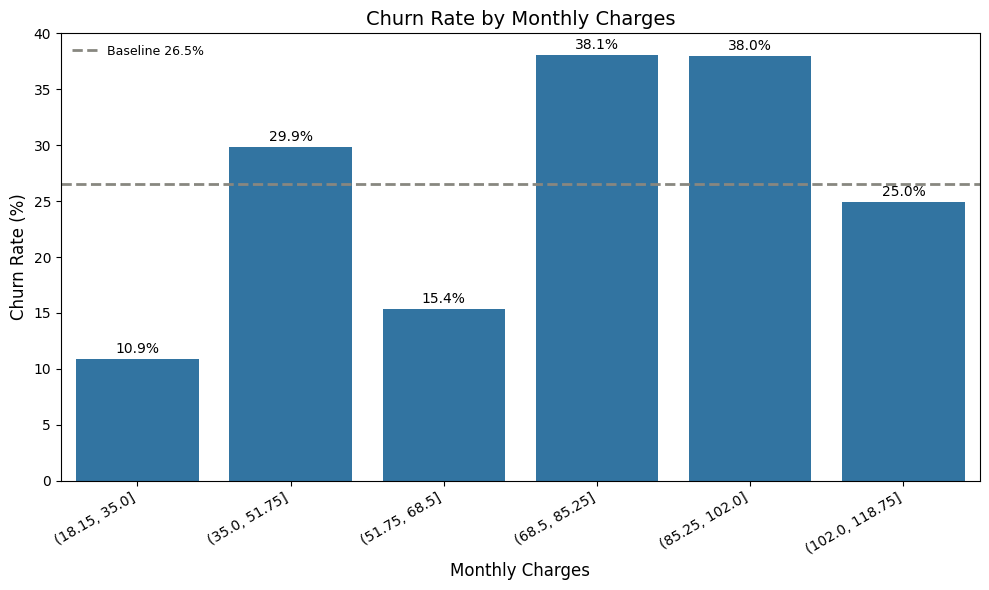

In [19]:
def plot_churn_by_monthly_charges(df, churn_col='Churn Value', bins=6, precision=2):
    # Create bins for Monthly Charges
    df_copy = df.copy()
    df_copy['Monthly Charges Bins'] = pd.cut(df_copy['Monthly Charges'], bins=bins, precision=precision)

    # Calculate churn rate for each bin
    churn_by_monthly_charges = df_copy.groupby('Monthly Charges Bins', observed=False)[churn_col].mean().reset_index()
    churn_by_monthly_charges['Churn Rate (%)'] = churn_by_monthly_charges[churn_col] * 100

    # Plotting the churn rate by monthly charges bins
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x='Monthly Charges Bins', y='Churn Rate (%)', data=churn_by_monthly_charges, legend=False)

    plt.title('Churn Rate by Monthly Charges', fontsize=14)
    plt.xlabel('Monthly Charges', fontsize=12)
    plt.ylabel('Churn Rate (%)', fontsize=12)
    plt.xticks(rotation=30, ha='right')

    # Remove horizontal grid lines
    ax.grid(False, axis='y')

    # Add baseline threshold line
    baseline_churn_rate = baseline['churn_rate'] # Access the baseline from the global scope
    ax.axhline(baseline_churn_rate, color='#888780', linestyle='--', linewidth=2, label=f'Baseline {baseline_churn_rate}%')
    ax.legend(fontsize=9, frameon=False, loc='upper left')

    # Add percentage labels on top of bars
    for index, row in churn_by_monthly_charges.iterrows():
        plt.text(index, row['Churn Rate (%)'] + 0.5, f"{row['Churn Rate (%)']:.1f}%", color='black', ha="center")

    plt.tight_layout()
    plt.show()

# call function
plot_churn_by_monthly_charges(df)

Key Takeaway:
- Customers that churn pay a higher average monthly charge
- Customers that are charged over $58 are more likely to churn.
- Customers that churn have a lower total charge on average. This is likely due to having a higher monthly charge, resulting in them leaving.

### 2.6 Multivariate Analysis

Multiple characteristic can be combined to identify high-risk customers.

The factor identified to be the strongest predictor of churn through single-factor analysis is the month-to-month contract type. Within each contract type, determine how churn rate vary when data is sliced by other factors with a higher-than-baseline churn rate.


In [21]:
def _add_tenure_band(df):
    """Creates tenure_band column if not already present."""
    if 'tenure_band' not in df.columns:
        df['tenure_band'] = pd.cut(
            df['Tenure Months'],
            bins=[0, 12, 24, 36, 72],
            labels=['0–12mo', '13–24mo', '25–36mo', '37–72mo']
        )
    return df

def build_contract_pivots(df, anchor='Contract', factors=None,
                          churn_col='Churn Label', churn_val='Yes'):
    """
    Builds churn rate pivot tables for anchor × each factor.

    Parameters
    ----------
    df       : source dataframe
    anchor   : the column to anchor every pivot on (default: 'Contract')
    factors  : list of columns to cross against the anchor — REQUIRED
    churn_col: column containing churn labels
    churn_val: value that represents a churned customer
    """
    if factors is None:
        raise ValueError(
            "No factors provided. Please pass a list of column names to cross "
            "against the anchor. Example:\n\n"
            "    build_contract_pivots(df, factors=['Internet Service', "
            "'tenure_band', 'Payment Method', 'Online Security', 'Senior Citizen'])"
        )

    df = _add_tenure_band(df.copy())

    def _churn_pivot(group_cols, unstack_col):
        return (
            df.groupby(group_cols, observed=True)[churn_col]
            .apply(lambda x: round((x == churn_val).mean() * 100, 1))
            .unstack(unstack_col)
        )

    pivots = {}
    for factor in factors:
        title = f'{anchor} × {factor}'
        pivots[title] = _churn_pivot([anchor, factor], factor)

    return pivots


def display_contract_pivots(pivots, anchor, anchor_val, baseline):
    """
    Prints each pivot table, flagging the anchor row and cells above baseline.

    Parameters
    ----------
    pivots  : dict returned by build_contract_pivots
    anchor  : the anchor contract value to highlight
    baseline: churn rate threshold to flag high-risk cells
    """
    # anchor_val = 'Month-to-month'

    for title, table in pivots.items():
        print(f"\n{'═' * 55}")
        print(f"  {title}")
        print(f"  Baseline churn rate: {baseline}%  |  ▲ = above baseline")
        print(f"{'═' * 55}")

        cols = list(table.columns)
        col_width = 14
        header = f"{'Contract':<22}" + "".join(f"{c:>{col_width}}" for c in cols)
        print(header)
        print("-" * len(header))

        for contract, row in table.iterrows():
            prefix = "▶ " if contract == anchor_val else "  "
            row_str = f"{prefix}{contract:<20}"
            for val in row:
                if pd.isna(val):
                    cell = "—"
                else:
                    flag = " ▲" if val > baseline else " "
                    cell = f"{val}%{flag}"
                row_str += f"{cell:>{col_width}}"
            print(row_str)
        print()


# --- Run it ---
anchor = 'Contract'
anchor_val = 'Month-to-month'
baseline = baseline['churn_rate']

factors = [
    'Internet Service', 'tenure_band',
    'Payment Method', 'Online Security', 'Senior Citizen'
]

# df, anchor='Contract', factors=None, churn_col='Churn Label', churn_val='Yes'

pivots = build_contract_pivots(df, anchor=anchor, factors=factors)
display_contract_pivots(pivots, anchor=anchor, anchor_val=anchor_val, baseline=baseline)


═══════════════════════════════════════════════════════
  Contract × Internet Service
  Baseline churn rate: 26.5%  |  ▲ = above baseline
═══════════════════════════════════════════════════════
Contract                         DSL   Fiber optic            No
----------------------------------------------------------------
▶ Month-to-month             32.2% ▲       54.6% ▲        18.9% 
  One year                     9.3%         19.3%          2.5% 
  Two year                     1.9%          7.2%          0.8% 


═══════════════════════════════════════════════════════
  Contract × tenure_band
  Baseline churn rate: 26.5%  |  ▲ = above baseline
═══════════════════════════════════════════════════════
Contract                      0–12mo       13–24mo       25–36mo       37–48mo       49–60mo       61–72mo
----------------------------------------------------------------------------------------------------------
▶ Month-to-month             51.4% ▲       37.7% ▲       32.5% ▲       33.5

In [22]:
# Rank the combinations of Contract Type with other individual factors

def rank_anchor_combinations(pivots, baseline, anchor_val='Month-to-month'):
    """
    Extracts the anchor row from each pivot table and ranks all
    factor levels by churn rate, highest to lowest.

    Parameters
    ----------
    pivots     : dict returned by build_contract_pivots
    anchor_val : the contract type row to extract (default: 'Month-to-month')
    baseline   : churn rate threshold to flag high-risk combinations
    """
    records = []

    for title, table in pivots.items():
        if anchor_val not in table.index:
            print(f"  Warning: '{anchor_val}' not found in {title}, skipping.")
            continue

        factor_name = title.split(' × ')[1]
        row = table.loc[anchor_val]

        for level, churn_rate in row.items():
            if pd.isna(churn_rate):
                continue
            records.append({
                'Factor': factor_name,
                'Level': str(level),
                'Churn Rate': churn_rate,
                'Above Baseline': churn_rate > baseline
            })

    ranking = (
        pd.DataFrame(records)
        .sort_values('Churn Rate', ascending=False)
        .reset_index(drop=True)
    )
    ranking.index += 1  # Start ranking at 1
    return ranking


# --- Run it ---
ranking = rank_anchor_combinations(pivots, baseline=baseline['churn_rate'])
print(ranking.to_string())

              Factor                      Level  Churn Rate  Above Baseline
1   Internet Service                Fiber optic        54.6            True
2     Senior Citizen                        Yes        54.6            True
3     Payment Method           Electronic check        53.7            True
4        tenure_band                     0–12mo        51.4            True
5    Online Security                         No        51.0            True
6     Senior Citizen                         No        39.6            True
7        tenure_band                    13–24mo        37.7            True
8     Payment Method  Bank transfer (automatic)        34.1            True
9        tenure_band                    37–48mo        33.5            True
10    Payment Method    Credit card (automatic)        32.8            True
11       tenure_band                    25–36mo        32.5            True
12  Internet Service                        DSL        32.2            True
13    Paymen

In [23]:
# Pull out factor pairs from rankings

def create_factor_pairs_list(ranking, select_n):
  ''' Extract the top n (factor, level) pairs from rankings as a tuple.'''
  factor_pairs_list = []
  for i in range(select_n):
    get_pairs = tuple(ranking.iloc[i][['Factor', 'Level']])
    factor_pairs_list.append(get_pairs)
  return factor_pairs_list

factor_pairs = create_factor_pairs_list(ranking, select_n=3)

In [24]:
# Get the next top three factors

def extract_third_factors(ranking, factor_pairs):
    """
    Extracts third factors from the ranking table by removing
    factors already present in factor_pairs.

    Parameters
    ----------
    ranking      : dataframe returned by rank_anchor_combinations
    factor_pairs : list of (factor, level) tuples returned by
                   extract_factor_pairs
    """
    if not factor_pairs:
        raise ValueError(
            "factor_pairs is empty. Please run extract_factor_pairs first. "
            "Example:\n\n"
            "    factor_pairs = extract_factor_pairs(ranking, top_n=3)\n"
            "    third_factors = extract_third_factors(ranking, factor_pairs)"
        )

    # get factors already used in pairs
    used_factors = {factor for factor, _ in factor_pairs}

    # get all unique factors in ranking
    all_factors = set(ranking['Factor'].unique())

    # remove used factors
    remaining = all_factors - used_factors

    # Step 5 — return as sorted list for consistency
    third_factors = sorted(remaining)

    print(f"Used factors (excluded): {sorted(used_factors)}")
    print(f"Extracted third factor(s): {third_factors}")

    return third_factors

third_factors = extract_third_factors(ranking, factor_pairs)

Used factors (excluded): ['Internet Service', 'Payment Method', 'Senior Citizen']
Extracted third factor(s): ['Online Security', 'tenure_band']


In [25]:
# Add a third factor to the above pivot table

def build_threeway_pivots(df, anchor_col='Contract', anchor_val='Month-to-month',
                          factor_pairs=None, third_factors=None,
                          churn_col='Churn Label', churn_val='Yes'):
    """
    Filters to anchor segment, then builds churn rate tables for
    factor_pair × third_factor combinations.

    Parameters
    ----------
    df            : source dataframe
    anchor_col    : column used to filter to the anchor segment
    anchor_val    : value to filter on (default: 'Month-to-month')
    factor_pairs  : list of (factor, level) tuples to filter on — REQUIRED
    third_factors : list of columns to cross against each pair — REQUIRED
    churn_col     : column containing churn labels
    churn_val     : value that represents a churned customer
    """
    if factor_pairs is None:
        raise ValueError(
            "No factor pairs provided. Please pass a list of (factor, level) tuples. "
            "Example:\n\n"
            "    factor_pairs=[('Internet Service', 'Fiber optic'), "
            "('tenure_band', '0–12mo')]"
        )
    if third_factors is None:
        raise ValueError(
            "No third factors provided. Please pass a list of column names. "
            "Example:\n\n"
            "    third_factors=['Payment Method', 'Online Security', 'Senior Citizen']"
        )

    df = df.copy()

    # Create tenure band if needed
    if 'tenure_band' in [f for f, _ in factor_pairs] + third_factors:
        if 'tenure_band' not in df.columns:
            df['tenure_band'] = pd.cut(
                df['Tenure Months'],
                bins=[0, 12, 24, 36, 72],
                labels=['0–12mo', '13–24mo', '25–36mo', '37–72mo']
            )

    # Filter to anchor segment
    anchor_df = df[df[anchor_col] == anchor_val].copy()

    results = {}
    for factor, level in factor_pairs:
        pair_df = anchor_df[anchor_df[factor] == level]
        pair_label = f"{anchor_val} + {level}"

        for third in third_factors:
            if third == factor:
                continue  # skip self-cross

            title = f"{pair_label} × {third}"
            table = (
                pair_df.groupby(third, observed=True)[churn_col]
                .apply(lambda x: round((x == churn_val).mean() * 100, 1))
                .rename('Churn Rate')
                .to_frame()
            )
            table['Count'] = pair_df.groupby(third, observed=True).size()
            table['Above Baseline'] = table['Churn Rate'] > baseline['churn_rate']
            results[title] = table.sort_values('Churn Rate', ascending=False)

    return results


def display_threeway_pivots(results):
    """
    Prints each three-way churn rate table.
    """
    for title, table in results.items():
        print(f"\n{'═' * 55}")
        print(f"  {title}")
        print(f"{'═' * 55}")
        print(table.to_string())
        print()


# --- Run it ---
#factor_pairs = create_factor_pairs_list(ranking, select_n=3)

#third_factors = extract_third_factors(ranking, factor_pairs)
# third_factors = ['Online Security', 'Senior Citizen', 'Monthly Charges']

threeway_results = build_threeway_pivots(df, factor_pairs=factor_pairs,
                                third_factors=third_factors)
display_threeway_pivots(threeway_results)


═══════════════════════════════════════════════════════
  Month-to-month + Fiber optic × Online Security
═══════════════════════════════════════════════════════
                 Churn Rate  Count  Above Baseline
Online Security                                   
No                     58.1   1774            True
Yes                    37.0    354            True


═══════════════════════════════════════════════════════
  Month-to-month + Fiber optic × tenure_band
═══════════════════════════════════════════════════════
             Churn Rate  Count  Above Baseline
tenure_band                                   
0–12mo             70.2    916            True
13–24mo            50.6    425            True
25–36mo            45.0    309            True
37–48mo            41.0    212            True
49–60mo            31.6    174            True
61–72mo            25.0     92           False


═══════════════════════════════════════════════════════
  Month-to-month + Yes × Online Security


In [26]:
def extract_profiles(df, threeway, anchor_col='Contract',
                     anchor_val='Month-to-month', top_n=1):
    """
    Extracts risk profiles from the three-way pivot results by
    selecting the top-churning third factor level for each pair.

    Parameters
    ----------
    df         : source dataframe
    threeway   : dict returned by build_threeway_pivots
    anchor_col : column used to filter to the anchor segment
    anchor_val : anchor value (default: 'Month-to-month')
    top_n      : number of third factor levels to extract per table
    """
    if not threeway:
        raise ValueError(
            "threeway is empty. Please run build_threeway_pivots first. "
            "Example:\n\n"
            "    threeway = build_threeway_pivots(df, factor_pairs=factor_pairs,\n"
            "                                    third_factors=third_factors)\n"
            "    profiles = extract_profiles(df, threeway)"
        )

    df = _add_tenure_band(df.copy())
    profiles = {}

    for title, table in threeway.items():
        # Step 2 — parse title to recover factor pair and third factor
        # title format: "{anchor_val} + {level} × {third_factor}"
        left, third_factor = title.split(' × ')
        pair_level = left.replace(f"{anchor_val} + ", "").strip()

        # recover the factor column name from df that contains pair_level
        pair_col = next(
            (col for col in df.columns if col != anchor_col
             and df[col].astype(str).eq(pair_level).any()),
            None
        )
        if pair_col is None:
            print(f"  Warning: could not resolve column for '{pair_level}', skipping.")
            continue

        # Step 2 — top N third factor levels by churn rate
        top_levels = table.head(top_n)

        for third_level, row in top_levels.iterrows():
            # Step 3 — construct boolean mask
            mask = (
                (df[anchor_col] == anchor_val) &
                (df[pair_col].astype(str) == pair_level) &
                (df[third_factor].astype(str) == str(third_level))
            )

            # Step 4 — assemble human-readable name
            label = f"{anchor_val} + {pair_level} {pair_col} + {third_level} {third_factor}" # add more readability

            profiles[label] = mask
            print(f"  Profile extracted: '{label}' "
                  f"(Churn Rate: {row['Churn Rate']}%)")

    return profiles

In [31]:
# Build risk profiles

def build_risk_profiles(df, profiles=None, churn_col='Churn Label', churn_val='Yes'):
    """
    Calculates churn rate and count for each named risk profile.

    Parameters
    ----------
    df       : source dataframe
    profiles : dict of {profile_name: boolean mask} — REQUIRED
    churn_col: column containing churn labels
    churn_val: value that represents a churned customer
    """
    if profiles is None:
        raise ValueError(
            "No profiles provided. Please pass a dict of named boolean masks. "
            "Example:\n\n"
            "    profiles={\n"
            "        'M2M + Fiber + 0–12mo': (\n"
            "            (df['Contract'] == 'Month-to-month') &\n"
            "            (df['Internet Service'] == 'Fiber optic') &\n"
            "            (df['tenure_band'] == '0–12mo')\n"
            "        )\n"
            "    }"
        )

    df = df.copy()

    if 'tenure_band' not in df.columns:
        df['tenure_band'] = pd.cut(
            df['Tenure Months'],
            bins=[0, 12, 72],
            labels=['0–12mo', '13–72mo']
        )

    records = []
    for label, mask in profiles.items():
        subset = df[mask]
        churn_rate = round((subset[churn_col] == churn_val).mean() * 100, 1)
        records.append({
            'Profile': label,
            'Count': len(subset),
            'Churn Rate': churn_rate,
            'Above Baseline': churn_rate > baseline['churn_rate']
        })

    return (
        pd.DataFrame(records)
        .set_index('Profile')
        .sort_values('Churn Rate', ascending=False)
    )


def plot_risk_profiles(risk_profiles, baseline=baseline['churn_rate']):
    """
    Plots compound risk profiles as a horizontal bar chart.
    """
    fig, ax = plt.subplots(figsize=(9, 4))
    colors = ['#D85A30' if r > baseline else '#1D9E75'
              for r in risk_profiles['Churn Rate']]

    sns.barplot(x='Churn Rate', y=risk_profiles.index,
                data=risk_profiles.reset_index(),
                palette=colors, ax=ax)

    ax.axvline(baseline, color='black', linestyle='--',
               linewidth=1, label=f'Baseline ({baseline}%)')
    ax.set_title('Compound risk profiles — churn rate')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_xlim(0, 80)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.legend(frameon=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()


profiles = extract_profiles(df, threeway_results)
risk_profiles = build_risk_profiles(df, profiles=profiles)

print(risk_profiles)

  Profile extracted: 'Month-to-month + Fiber optic Internet Service + No Online Security' (Churn Rate: 58.1%)
  Profile extracted: 'Month-to-month + Fiber optic Internet Service + 0–12mo tenure_band' (Churn Rate: 70.2%)
  Profile extracted: 'Month-to-month + Yes Senior Citizen + No Online Security' (Churn Rate: 58.2%)
  Profile extracted: 'Month-to-month + Yes Senior Citizen + 0–12mo tenure_band' (Churn Rate: 68.2%)
  Profile extracted: 'Month-to-month + Electronic check Payment Method + No Online Security' (Churn Rate: 58.6%)
  Profile extracted: 'Month-to-month + Electronic check Payment Method + 0–12mo tenure_band' (Churn Rate: 63.1%)
                                                    Count  Churn Rate  \
Profile                                                                 
Month-to-month + Fiber optic Internet Service +...    916        70.2   
Month-to-month + Yes Senior Citizen + 0–12mo te...    318        68.2   
Month-to-month + Electronic check Payment Metho...    954     

/tmp/ipykernel_7154/2916594888.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Churn Rate', y=risk_profiles.index,


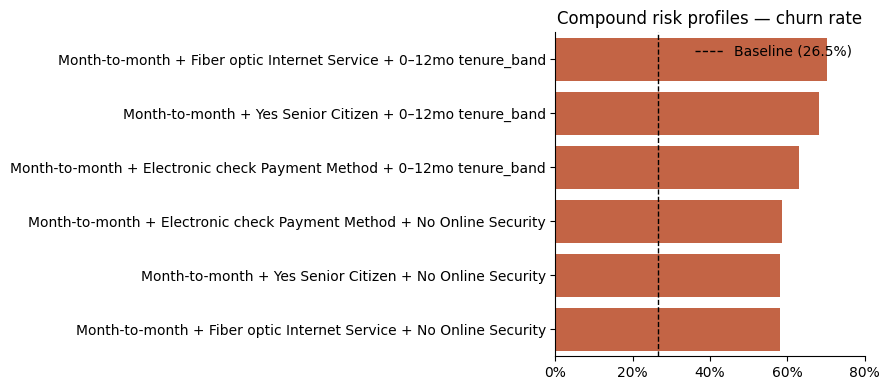

In [32]:
plot_risk_profiles(risk_profiles, baseline=baseline['churn_rate'])

### 2.7 Churn Score Distribution

Does the churn score give an accurate prediction of whether a customer will churn or not?

In [29]:
# Separate customers into churned and retained groups
churned_customers = df[df['Churn Label'] == 'Yes']
retained_customers = df[df[ 'Churn Label'] == 'No']

# Describe the Churn Score for each group
print("Descriptive statistics for Churn Score (Churned Customers):")
display(churned_customers['Churn Score'].describe())

print("\nDescriptive statistics for Churn Score (Retained Customers):")
display(retained_customers['Churn Score'].describe())

Descriptive statistics for Churn Score (Churned Customers):


,Churn Score
count,1869.000000
mean,82.510433
std,10.328570
min,65.000000
25%,74.000000
50%,82.000000
75%,91.000000
max,100.000000



Descriptive statistics for Churn Score (Retained Customers):


,Churn Score
count,5174.000000
mean,50.098183
std,17.702277
min,5.000000
25%,35.000000
50%,50.000000
75%,66.000000
max,80.000000


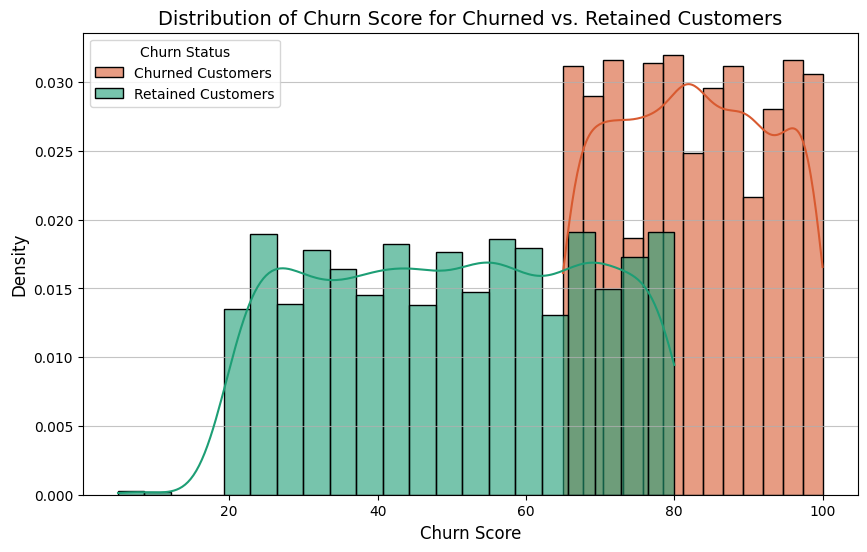

In [30]:
plt.figure(figsize=(10, 6))
sns.histplot(churned_customers['Churn Score'], color='#D85A30', kde=True, stat='density', alpha=0.6, label='Churned Customers')
sns.histplot(retained_customers['Churn Score'], color='#1D9E75', kde=True, stat='density', alpha=0.6, label='Retained Customers')

plt.title('Distribution of Churn Score for Churned vs. Retained Customers', fontsize=14)
plt.xlabel('Churn Score', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Churn Status')
plt.grid(axis='y', alpha=0.75)
plt.show()